# Advances in Financial Machine Learning - 标签生成与建模

本Notebook按照《Advances in Financial Machine Learning》书中的方法：
1. 计算对数收益率
2. 使用Triple Barrier Method生成标签
3. 使用Meta-Labeling进行二次过滤
4. 构建基础预测模型

数据来源: Dollar Bars (test_dollar.csv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体和样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

print("库导入完成")

库导入完成


## 1. 数据加载与预处理

In [2]:
# 加载Dollar Bars数据
df = pd.read_csv('../data/test_dollar.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print(f"数据形状: {df.shape}")
print(f"时间范围: {df.index.min()} 到 {df.index.max()}")
df.head()

数据形状: (3697, 5)
时间范围: 2026-03-01 00:00:00.005000 到 2026-03-31 23:36:44.263000


,open,high,low,close,volume
timestamp,,,,,
2026-03-01 00:00:00.005,0.09399,0.09422,0.09376,0.09376,53199900
2026-03-01 00:19:11.235,0.09375,0.09391,0.09357,0.09358,53609441
2026-03-01 00:41:35.113,0.09357,0.09392,0.09347,0.09372,54802346
2026-03-01 01:00:38.088,0.09372,0.09377,0.09363,0.09377,53600052
2026-03-01 01:01:47.687,0.09377,0.09390,0.09317,0.09322,53410444


In [3]:
# 数据基本统计
df.describe()

,open,high,low,close,volume
count,3697.000000,3697.000000,3697.000000,3697.000000,3.697000e+03
mean,0.094379,0.094629,0.094133,0.094379,5.337357e+07
std,0.003534,0.003541,0.003515,0.003534,2.468379e+06
min,0.086590,0.087020,0.086530,0.086600,4.117621e+07
25%,0.091620,0.091870,0.091380,0.091620,5.208454e+07
50%,0.093910,0.094170,0.093660,0.093910,5.344635e+07
75%,0.096290,0.096520,0.096040,0.096290,5.481428e+07
max,0.104100,0.104450,0.103790,0.104100,8.949196e+07


## 2. 计算对数收益率

In [4]:
# 计算close价格的对数收益率
df['log_return'] = np.log(df['close'] / df['close'].shift(1))
df['returns'] = df['close'].pct_change()  # 简单收益率

# 删除NaN
df_clean = df.dropna().copy()

print(f"清理后数据形状: {df_clean.shape}")
df_clean[['close', 'log_return', 'returns']].head(10)

清理后数据形状: (3696, 7)


,close,log_return,returns
timestamp,,,
2026-03-01 00:19:11.235,0.09358,-0.001922,-0.001920
2026-03-01 00:41:35.113,0.09372,0.001495,0.001496
2026-03-01 01:00:38.088,0.09377,0.000533,0.000534
2026-03-01 01:01:47.687,0.09322,-0.005883,-0.005865
2026-03-01 01:11:08.402,0.09331,0.000965,0.000965
2026-03-01 01:16:03.079,0.09379,0.005131,0.005144
2026-03-01 01:26:12.110,0.09437,0.006165,0.006184
2026-03-01 01:37:19.257,0.09461,0.002540,0.002543
2026-03-01 01:48:11.135,0.09512,0.005376,0.005391


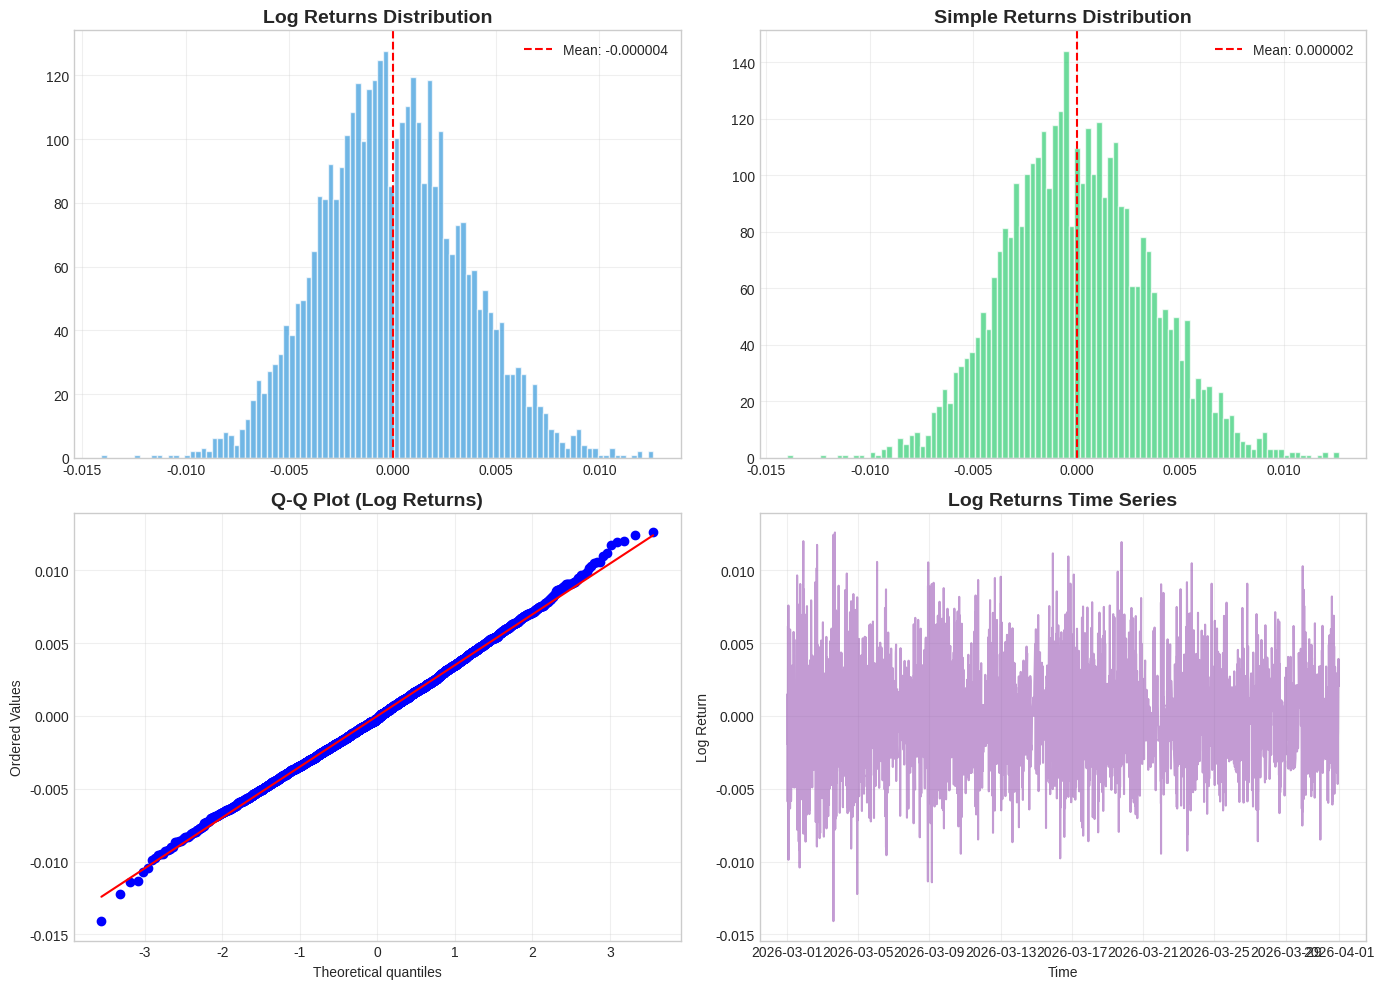


=== 收益率统计信息 ===
偏度 (Skewness): 0.1337
峰度 (Kurtosis): 0.0962
均值 (Mean): -0.00000430
标准差 (Std): 0.00348808


In [5]:
# 可视化收益率分布
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Log Returns直方图
axes[0, 0].hist(df_clean['log_return'], bins=100, density=True, alpha=0.7, color='#3498db', edgecolor='white')
axes[0, 0].set_title('Log Returns Distribution', fontsize=14, fontweight='bold')
axes[0, 0].axvline(df_clean['log_return'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['log_return'].mean():.6f}")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Simple Returns直方图
axes[0, 1].hist(df_clean['returns'], bins=100, density=True, alpha=0.7, color='#2ecc71', edgecolor='white')
axes[0, 1].set_title('Simple Returns Distribution', fontsize=14, fontweight='bold')
axes[0, 1].axvline(df_clean['returns'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['returns'].mean():.6f}")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Q-Q图
stats.probplot(df_clean['log_return'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Log Returns)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# 时间序列图
axes[1, 1].plot(df_clean.index, df_clean['log_return'], alpha=0.6, color='#9b59b6')
axes[1, 1].set_title('Log Returns Time Series', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Time')
axes[1, 1].set_ylabel('Log Return')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 统计信息
print("\n=== 收益率统计信息 ===")
print(f"偏度 (Skewness): {df_clean['log_return'].skew():.4f}")
print(f"峰度 (Kurtosis): {df_clean['log_return'].kurt():.4f}")
print(f"均值 (Mean): {df_clean['log_return'].mean():.8f}")
print(f"标准差 (Std): {df_clean['log_return'].std():.8f}")

## 3. Triple Barrier Method 标签生成

根据书中2.3节的方法，使用三个屏障来生成标签：
- **上 barrier (profit-taking)**: 设定盈利目标
- **下 barrier (stop-loss)**: 设定止损线
- **时间 barrier**: 设定最大持有时间

标签定义：
- 1: 先触及上barrier（做多信号）
- -1: 先触及下barrier（做空信号）
- 0: 先触及时间barrier（无明确信号）

In [6]:
df.head()


,open,high,low,close,volume,log_return,returns
timestamp,,,,,,,
2026-03-01 00:00:00.005,0.09399,0.09422,0.09376,0.09376,53199900,NaN,NaN
2026-03-01 00:19:11.235,0.09375,0.09391,0.09357,0.09358,53609441,-0.001922,-0.001920
2026-03-01 00:41:35.113,0.09357,0.09392,0.09347,0.09372,54802346,0.001495,0.001496
2026-03-01 01:00:38.088,0.09372,0.09377,0.09363,0.09377,53600052,0.000533,0.000534
2026-03-01 01:01:47.687,0.09377,0.09390,0.09317,0.09322,53410444,-0.005883,-0.005865


In [ ]:
def get_triple_barrier_labels(df, price_col='close', lookback=20, pt_sl_multiplier=[2, 2], horizon=10):
    """
    实现 Triple Barrier Method 标签生成，并记录真实退出收益。
    
    参数:
    - df: DataFrame包含价格数据
    - price_col: 价格列名
    - lookback: 计算波动率的回看期
    - pt_sl_multiplier: [profit_taking_multiplier, stop_loss_multiplier]
    - horizon: 时间barrier（最大持有期）
    
    返回:
    - labels: Series，标签值 {1, -1, 0}
    - barriers: DataFrame，包含barrier、退出时刻、退出价格和真实收益
    """
    df.dropna(inplace=True)
    # 1. 计算波动率（使用标准差）
    daily_vol = df[price_col].pct_change().rolling(window=lookback).std()
    
    # 2. 设置barriers
    barriers = pd.DataFrame(index=df.index)
    
    # 时间barrier
    #barriers['t1'] = df.index + pd.Timedelta(days=horizon)  # 这里horizon以bar为单位
    # 对于高频数据，使用bar数量
    barriers['t1'] = df.index.to_series().shift(-horizon)  # 向前推horizon个bar
    
    # 上下barrier的价格
    # pt_sl_multiplier可以是单个值或列表[profit_taking, stop_loss]
    if isinstance(pt_sl_multiplier, (list, tuple)):
        pt = daily_vol * float(pt_sl_multiplier[0])#2
        sl = daily_vol * float(pt_sl_multiplier[1])#2
    else:
        pt = daily_vol * float(pt_sl_multiplier)
        sl = daily_vol * float(pt_sl_multiplier)
    
    barriers['upper'] = df[price_col] * (1 + pt)
    barriers['lower'] = df[price_col] * (1 - sl)
    
    # 3. 计算每个bar的标签
    labels = pd.Series(index=df.index, dtype=int)
    barriers['exit_time'] = pd.NaT
    barriers['exit_price'] = np.nan
    barriers['exit_label'] = np.nan
    barriers['barrier_return'] = np.nan
    barriers['barrier_log_return'] = np.nan
    barriers['exit_reason'] = None
    
    for idx in df.index:
        if pd.isna(barriers.loc[idx, 't1']) or pd.isna(barriers.loc[idx, 'upper']) or pd.isna(barriers.loc[idx, 'lower']):
            continue
            
        # 获取当前bar的信息
        start_price = df.loc[idx, price_col]
        upper_barrier = barriers.loc[idx, 'upper']
        lower_barrier = barriers.loc[idx, 'lower']
        end_time = barriers.loc[idx, 't1']
        
        # 获取从当前bar到时间barrier之间的价格序列
        if end_time in df.index:
            price_series = df.loc[idx:end_time, price_col]
        else:
            # 如果end_time不在index中，取之后的所有数据
            price_series = df.loc[idx:, price_col]
            if len(price_series) > horizon:
                price_series = price_series.iloc[:horizon+1]
        
        # 默认按时间barrier退出
        label = 0
        exit_time = price_series.index[-1]
        exit_price = price_series.iloc[-1]
        exit_reason = 'time'
        
        # 从下一根bar开始检查是否先触发上下barrier
        for timestamp, price in price_series.iloc[1:].items():
            if price >= upper_barrier:
                label = 1
                exit_time = timestamp
                exit_price = price
                exit_reason = 'upper'
                break
            elif price <= lower_barrier:
                label = -1
                exit_time = timestamp
                exit_price = price
                exit_reason = 'lower'
                break
        
        realized_return = exit_price / start_price - 1
        realized_log_return = np.log(exit_price / start_price)
        labels.loc[idx] = label
        barriers.loc[idx, 'exit_time'] = exit_time
        barriers.loc[idx, 'exit_price'] = exit_price
        barriers.loc[idx, 'exit_label'] = label
        barriers.loc[idx, 'barrier_return'] = realized_return
        barriers.loc[idx, 'barrier_log_return'] = realized_log_return
        barriers.loc[idx, 'exit_reason'] = exit_reason
    
    return labels, barriers

print("Triple Barrier函数定义完成")

Triple Barrier函数定义完成


标签分布:
-1.0    1809
 1.0    1664
 0.0     193
Name: count, dtype: int64

标签占比:
-1.0    0.493453
 1.0    0.453901
 0.0    0.052646
Name: proportion, dtype: float64


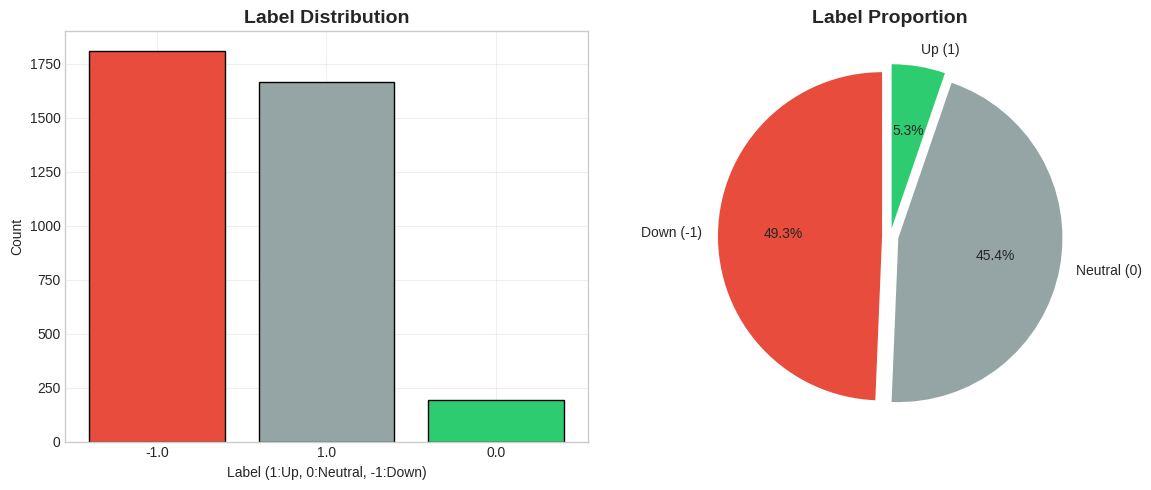

In [8]:
# 应用Triple Barrier Method
labels, barriers = get_triple_barrier_labels(
    df_clean, 
    price_col='close',
    lookback=20,  # 20个bar计算波动率
    pt_sl_multiplier=[1.5, 1.5],  # 1.5倍标准差
    horizon=10  # 10个bar后强制平仓
)

# 将标签和真实退出结果添加到DataFrame
df_clean['label'] = labels
df_clean['tb_return'] = barriers['barrier_return']
df_clean['tb_log_return'] = barriers['barrier_log_return']
df_clean['tb_exit_time'] = barriers['exit_time']
df_clean['tb_exit_reason'] = barriers['exit_reason']

print("标签分布:")
print(labels.value_counts())
print(f"\n标签占比:")
print(labels.value_counts(normalize=True))

# 可视化标签分布
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 柱状图
label_counts = labels.value_counts()
axes[0].bar(label_counts.index.astype(str), label_counts.values, 
           color=['#e74c3c', '#95a5a6', '#2ecc71'], edgecolor='black')
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label (1:Up, 0:Neutral, -1:Down)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# 饼图
axes[1].pie(label_counts.values, labels=['Down (-1)', 'Neutral (0)', 'Up (1)'], 
           autopct='%1.1f%%', colors=['#e74c3c', '#95a5a6', '#2ecc71'],
           startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title('Label Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. 特征工程

根据书中方法，构建用于预测的特征：
1. 波动率特征
2. 动量特征
3. 成交量特征
4. OHLC关系特征

In [9]:
import talib

def create_features(df, price_col='close', volume_col='volume'):
    """创建特征 - 使用TA-Lib优化"""
    df_feat = df.copy()
    
    # 获取价格数组 (转换为float64以满足TA-Lib要求)
    close = df_feat[price_col].values.astype(np.float64)
    high = df_feat['high'].values.astype(np.float64)
    low = df_feat['low'].values.astype(np.float64)
    open_price = df_feat['open'].values.astype(np.float64)
    volume = df_feat[volume_col].values.astype(np.float64)
    
    # 1. 波动率特征（基于收益率，更平稳）
    df_feat['vol_5'] = df_feat['log_return'].rolling(window=5).std()
    df_feat['vol_10'] = df_feat['log_return'].rolling(window=10).std()
    df_feat['vol_20'] = df_feat['log_return'].rolling(window=20).std()
    
    # 2. 动量特征 (使用ROC - Rate of Change)
    df_feat['momentum_3'] = talib.ROC(close, timeperiod=3) / 100  # ROC返回百分比
    df_feat['momentum_5'] = talib.ROC(close, timeperiod=5) / 100
    df_feat['momentum_10'] = talib.ROC(close, timeperiod=10) / 100
    
    # 3. 成交量特征
    df_feat['volume_ma_5'] = talib.SMA(volume, timeperiod=5)
    df_feat['volume_ma_10'] = talib.SMA(volume, timeperiod=10)
    df_feat['volume_ratio'] = volume / df_feat['volume_ma_10']
    
    # 4. OHLC关系特征
    df_feat['high_low_spread'] = (df_feat['high'] - df_feat['low']) / df_feat['close']
    df_feat['open_close_spread'] = (df_feat['close'] - df_feat['open']) / df_feat['close']
    
    # 5. RSI (使用TA-Lib)
    df_feat['rsi'] = talib.RSI(close, timeperiod=14)
    
    # 6. 价格位置 (0-1之间) - 使用TA-Lib的MIN/MAX
    min_20 = talib.MIN(low, timeperiod=20)
    max_20 = talib.MAX(high, timeperiod=20)
    df_feat['price_position'] = (close - min_20) / (max_20 - min_20)
    
    # 可选：添加更多TA-Lib指标
    # ATR (平均真实波幅)
    df_feat['atr'] = talib.ATR(high, low, close, timeperiod=14)
    
    # MACD
    df_feat['macd'], df_feat['macd_signal'], df_feat['macd_hist'] = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    
    # 布林带
    df_feat['bb_upper'], df_feat['bb_middle'], df_feat['bb_lower'] = talib.BBANDS(close, timeperiod=20)
    df_feat['bb_position'] = (close - df_feat['bb_lower']) / (df_feat['bb_upper'] - df_feat['bb_lower'])
    
    return df_feat

# 创建特征
df_featured = create_features(df_clean)

# 选择特征列
feature_cols = ['vol_5', 'vol_10', 'vol_20', 
                'momentum_3', 'momentum_5', 'momentum_10',
                'volume_ma_5', 'volume_ma_10', 'volume_ratio',
                'high_low_spread', 'open_close_spread',
                'rsi', 'price_position']

# 保留建模与回测所需字段，统一索引并一起dropna
model_cols = feature_cols + ['label', 'close', 'log_return', 'returns', 'tb_return', 'tb_log_return', 'tb_exit_time', 'tb_exit_reason']
df_model = df_featured[model_cols].dropna().copy()

print(f"特征工程后数据形状: {df_model.shape}")
print(f"\n特征列表: {feature_cols}")
df_model.head()

特征工程后数据形状: (3666, 21)

特征列表: ['vol_5', 'vol_10', 'vol_20', 'momentum_3', 'momentum_5', 'momentum_10', 'volume_ma_5', 'volume_ma_10', 'volume_ratio', 'high_low_spread', 'open_close_spread', 'rsi', 'price_position']


,vol_5,vol_10,vol_20,momentum_3,momentum_5,momentum_10,volume_ma_5,volume_ma_10,volume_ratio,high_low_spread,...,rsi,price_position,label,close,log_return,returns,tb_return,tb_log_return,tb_exit_time,tb_exit_reason
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-03-01 02:23:00.804,0.005510,0.005364,0.004424,-0.002881,-0.007984,0.015082,51579733.8,51826741.8,0.998147,0.006500,...,71.150689,0.805383,-1.0,0.09692,0.000103,0.000103,-0.007326,-0.007353,2026-03-01 03:17:52.751,lower
2026-03-01 02:30:15.343,0.003071,0.005266,0.004424,0.002788,0.003825,0.012512,51637730.2,51623417.7,1.000554,0.004325,...,72.300871,0.844720,-1.0,0.09711,0.001958,0.001960,-0.009268,-0.009311,2026-03-01 03:17:52.751,lower
2026-03-01 02:38:02.503,0.002245,0.004780,0.004415,0.003508,0.000514,0.006312,51622341.8,51582124.0,0.998637,0.005039,...,73.150304,0.873706,-1.0,0.09725,0.001441,0.001442,-0.010694,-0.010752,2026-03-01 03:17:52.751,lower
2026-03-01 02:45:26.556,0.002642,0.004535,0.004308,-0.001238,-0.000413,-0.004934,52952204.0,52242234.7,1.113647,0.007748,...,66.130363,0.780538,-1.0,0.09680,-0.004638,-0.004627,-0.008678,-0.008716,2026-03-01 03:41:16.086,lower
2026-03-01 02:49:45.813,0.003010,0.004672,0.004311,-0.000103,0.001961,-0.001132,53010885.4,52283112.5,0.994212,0.003502,...,68.313519,0.842650,-1.0,0.09710,0.003094,0.003099,-0.009166,-0.009208,2026-03-01 03:17:52.751,lower


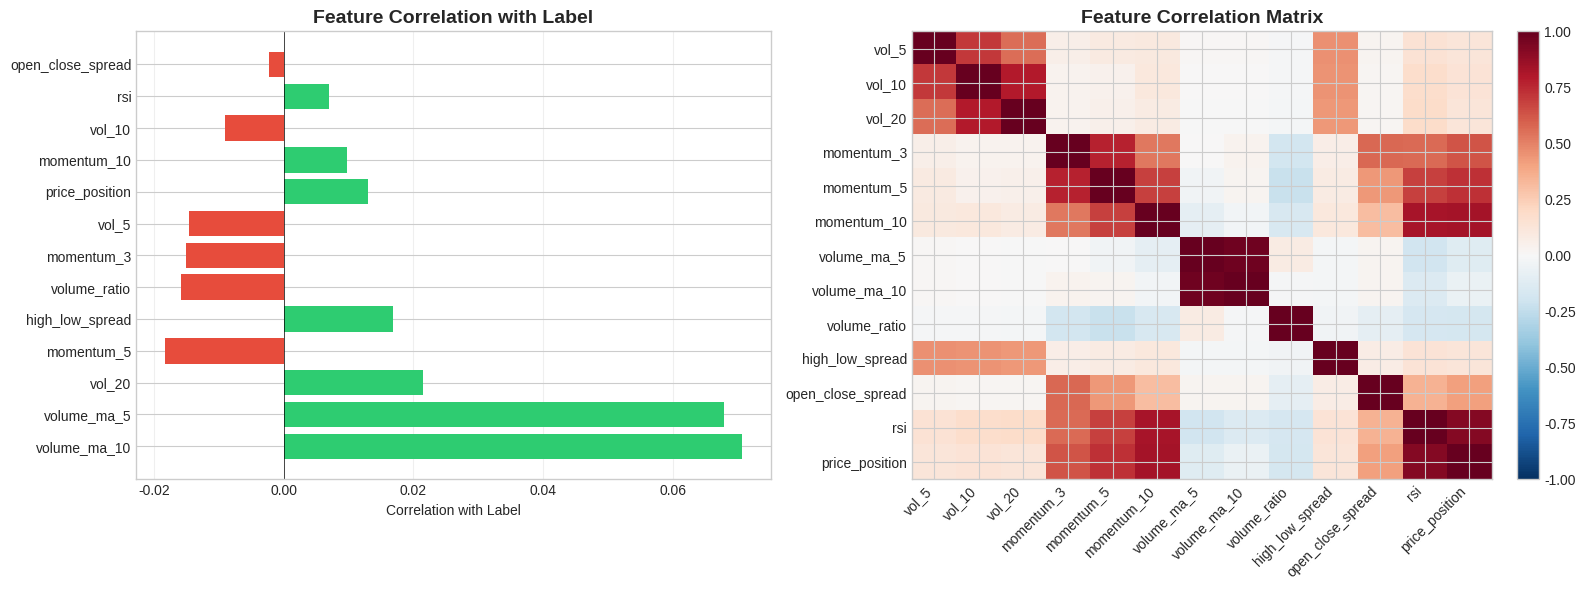


=== Top 5 特征与标签相关性 ===
volume_ma_10       0.070646
volume_ma_5        0.067907
vol_20             0.021483
momentum_5        -0.018312
high_low_spread    0.016923
Name: label, dtype: float64


In [10]:
# 特征相关性分析
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 特征与标签的相关性
corr_with_label = df_model[feature_cols + ['label']].corr()['label'].drop('label').sort_values(key=abs, ascending=False)

axes[0].barh(range(len(corr_with_label)), corr_with_label.values, 
             color=['#e74c3c' if x < 0 else '#2ecc71' for x in corr_with_label.values])
axes[0].set_yticks(range(len(corr_with_label)))
axes[0].set_yticklabels(corr_with_label.index)
axes[0].set_xlabel('Correlation with Label')
axes[0].set_title('Feature Correlation with Label', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3, axis='x')

# 特征间相关性热图
corr_matrix = df_model[feature_cols].corr()
im = axes[1].imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(feature_cols)))
axes[1].set_xticklabels(feature_cols, rotation=45, ha='right')
axes[1].set_yticks(range(len(feature_cols)))
axes[1].set_yticklabels(feature_cols)
axes[1].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\n=== Top 5 特征与标签相关性 ===")
print(corr_with_label.head(5))

## 5. 模型训练与评估

使用书中推荐的方法：
1. 主模型：预测方向（Triple Barrier标签）
2. Meta-Labeling：预测是否执行交易（过滤假信号）

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

# 准备数据
X = df_model[feature_cols].values
y = df_model['label'].values

# 将标签转换为二分类 (1 vs 其他)
y_binary = (y == 1).astype(int)  # 预测是否上涨

# 时间序列三段切分：train / validation / test
n_samples = len(X)
train_end = int(n_samples * 0.6)
val_end = int(n_samples * 0.8)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y_binary[:train_end], y_binary[train_end:val_end], y_binary[val_end:]

print(f"训练集大小: {X_train.shape}")
print(f"验证集大小: {X_val.shape}")
print(f"测试集大小: {X_test.shape}")
print(f"\n训练集标签分布: {np.bincount(y_train)}")
print(f"验证集标签分布: {np.bincount(y_val)}")
print(f"测试集标签分布: {np.bincount(y_test)}")

# 标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

训练集大小: (2199, 13)
验证集大小: (733, 13)
测试集大小: (734, 13)

训练集标签分布: [1173 1026]
验证集标签分布: [426 307]
测试集标签分布: [403 331]


In [12]:
# 1. 主模型：随机森林
print("="*60)
print("主模型: Random Forest")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)
rf_val_pred = rf_model.predict(X_val_scaled)
rf_val_pred_proba = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_test_pred = rf_model.predict(X_test_scaled)
rf_test_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("\nValidation 分类报告:")
print(classification_report(y_val, rf_val_pred, target_names=['Not Up', 'Up']))
print(f"Validation ROC-AUC: {roc_auc_score(y_val, rf_val_pred_proba):.4f}")

print("\nTest 分类报告:")
print(classification_report(y_test, rf_test_pred, target_names=['Not Up', 'Up']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, rf_test_pred_proba):.4f}")

# 特征重要性
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n特征重要性:")
print(feature_importance)

主模型: Random Forest

Validation 分类报告:
              precision    recall  f1-score   support

      Not Up       0.58      0.65      0.61       426
          Up       0.41      0.34      0.37       307

    accuracy                           0.52       733
   macro avg       0.50      0.50      0.49       733
weighted avg       0.51      0.52      0.51       733

Validation ROC-AUC: 0.4794

Test 分类报告:
              precision    recall  f1-score   support

      Not Up       0.58      0.51      0.54       403
          Up       0.48      0.55      0.51       331

    accuracy                           0.53       734
   macro avg       0.53      0.53      0.53       734
weighted avg       0.53      0.53      0.53       734

Test ROC-AUC: 0.5403

特征重要性:
              feature  importance
7        volume_ma_10    0.096946
1              vol_10    0.095866
6         volume_ma_5    0.093907
2              vol_20    0.090396
11                rsi    0.086338
0               vol_5    0.080442
4  

In [13]:
# 2. 主模型：梯度提升
print("\n" + "="*60)
print("主模型: Gradient Boosting")
print("="*60)

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train_scaled, y_train)
gb_val_pred = gb_model.predict(X_val_scaled)
gb_val_pred_proba = gb_model.predict_proba(X_val_scaled)[:, 1]
gb_test_pred = gb_model.predict(X_test_scaled)
gb_test_pred_proba = gb_model.predict_proba(X_test_scaled)[:, 1]

print("\nValidation 分类报告:")
print(classification_report(y_val, gb_val_pred, target_names=['Not Up', 'Up']))
print(f"Validation ROC-AUC: {roc_auc_score(y_val, gb_val_pred_proba):.4f}")

print("\nTest 分类报告:")
print(classification_report(y_test, gb_test_pred, target_names=['Not Up', 'Up']))
print(f"Test ROC-AUC: {roc_auc_score(y_test, gb_test_pred_proba):.4f}")


主模型: Gradient Boosting

Validation 分类报告:
              precision    recall  f1-score   support

      Not Up       0.59      0.57      0.58       426
          Up       0.43      0.45      0.44       307

    accuracy                           0.52       733
   macro avg       0.51      0.51      0.51       733
weighted avg       0.52      0.52      0.52       733

Validation ROC-AUC: 0.5070

Test 分类报告:
              precision    recall  f1-score   support

      Not Up       0.58      0.52      0.55       403
          Up       0.48      0.55      0.51       331

    accuracy                           0.53       734
   macro avg       0.53      0.53      0.53       734
weighted avg       0.54      0.53      0.53       734

Test ROC-AUC: 0.5464


## 6. Meta-Labeling (元标签)

根据书中3.5节，使用Meta-Labeling来过滤主模型的预测：
- 主模型预测方向
- Meta模型预测是否执行交易（基于主模型预测的置信度）

In [14]:
def apply_meta_labeling(df_slice, main_model, scaler, feature_cols):
    """
    为给定时间切片构造 Meta-Labeling 数据集（改进版）。
    
    针对主模型给出明确方向信号（做多或做空）的样本，
    判断这笔交易最终是否盈利。
    """
    
    # 主模型预测
    X_primary = scaler.transform(df_slice[feature_cols].values)
    main_pred = main_model.predict(X_primary)
    main_proba = main_model.predict_proba(X_primary)
    
    # 获取类别索引
    classes = main_model.classes_
    up_idx = np.where(classes == 1)[0][0] if 1 in classes else None
    down_idx = np.where(classes == -1)[0][0] if -1 in classes else None
    
    df_meta = df_slice.copy()
    df_meta['main_pred'] = main_pred
    
    # 根据预测方向获取对应概率
    if up_idx is not None:
        df_meta['up_proba'] = main_proba[:, up_idx]
    else:
        df_meta['up_proba'] = 0
    
    if down_idx is not None:
        df_meta['down_proba'] = main_proba[:, down_idx]
    else:
        df_meta['down_proba'] = 0
    
    # Meta-Labeling 针对主模型给出明确方向信号的样本（做多或做空）
    df_meta = df_meta[(df_meta['main_pred'] == 1) | (df_meta['main_pred'] == -1)].copy()
    
    # Meta标签：这笔候选交易最终是否盈利（基于tb_log_return）
    df_meta['meta_label'] = (df_meta['tb_log_return'] > 0).astype(int)
    
    return df_meta

# 用 validation 集构造 meta 训练数据，用 test 集做最终评估
df_meta_val = apply_meta_labeling(
    df_model.iloc[train_end:val_end].copy(),
    rf_model,
    scaler,
    feature_cols
)
df_meta_test = apply_meta_labeling(
    df_model.iloc[val_end:].copy(),
    rf_model,
    scaler,
    feature_cols
)

print("Validation 主模型方向信号数量:", len(df_meta_val))
print("  - 做多信号:", (df_meta_val['main_pred'] == 1).sum())
print("  - 做空信号:", (df_meta_val['main_pred'] == -1).sum())
print("Validation Meta-Labeling 分布:")
print(df_meta_val['meta_label'].value_counts())

print("\nTest 主模型方向信号数量:", len(df_meta_test))
print("  - 做多信号:", (df_meta_test['main_pred'] == 1).sum())
print("  - 做空信号:", (df_meta_test['main_pred'] == -1).sum())
print("Test Meta-Labeling 分布:")
print(df_meta_test['meta_label'].value_counts())

Validation 主模型方向信号数量: 251
  - 做多信号: 251
  - 做空信号: 0
Validation Meta-Labeling 分布:
meta_label
0    145
1    106
Name: count, dtype: int64

Test 主模型方向信号数量: 378
  - 做多信号: 378
  - 做空信号: 0
Test Meta-Labeling 分布:
meta_label
0    193
1    185
Name: count, dtype: int64


In [15]:
# 训练Meta模型（改进版）
print("\n" + "="*60)
print("Meta Model Training (Improved)")
print("="*60)

# 用 validation 集训练 Meta 模型
# 特征：主模型预测概率 + 原始特征
X_meta_train_base = scaler.transform(df_meta_val[feature_cols].values)

# 使用对应方向的概率作为额外特征
direction_proba = np.where(
    df_meta_val['main_pred'] == 1,
    df_meta_val['up_proba'].values,
    df_meta_val['down_proba'].values
)
X_meta_train = np.column_stack([direction_proba, X_meta_train_base])
y_meta_train = df_meta_val['meta_label'].values

meta_class_counts = pd.Series(y_meta_train).value_counts().sort_index()
print("Validation Meta标签计数:")
print(meta_class_counts)

if len(meta_class_counts) < 2:
    raise ValueError(
        "Validation 段的 Meta 标签只有一个类别，无法训练 meta model。请扩大样本或调整主模型阈值。"
    )

# Meta模型（使用逻辑回归）
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(random_state=42, max_iter=1000)
meta_model.fit(X_meta_train, y_meta_train)

# 在最终 test 集上做 out-of-sample 评估
X_meta_test_base = scaler.transform(df_meta_test[feature_cols].values)
test_direction_proba = np.where(
    df_meta_test['main_pred'] == 1,
    df_meta_test['up_proba'].values,
    df_meta_test['down_proba'].values
)
X_meta_test = np.column_stack([test_direction_proba, X_meta_test_base])
y_meta_test = df_meta_test['meta_label'].values

meta_pred = meta_model.predict(X_meta_test) 
meta_pred_proba = meta_model.predict_proba(X_meta_test)[:, 1]

print("\nMeta Model Test 分类报告:")
print(classification_report(y_meta_test, meta_pred, target_names=['Do Not Trade', 'Trade']))
print(f"Test ROC-AUC: {roc_auc_score(y_meta_test, meta_pred_proba):.4f}")

# 分析Meta模型的效果
print("\n=== Meta模型分析 ===")
print(f"Meta模型准确率: {meta_model.score(X_meta_test, y_meta_test):.4f}")
print(f"平均预测概率: {meta_pred_proba.mean():.4f}")
print(f"预测为'交易'的比例: {(meta_pred == 1).mean():.2%}")


Meta Model Training (Improved)
Validation Meta标签计数:
0    145
1    106
Name: count, dtype: int64

Meta Model Test 分类报告:
              precision    recall  f1-score   support

Do Not Trade       0.53      0.82      0.65       193
       Trade       0.57      0.25      0.35       185

    accuracy                           0.54       378
   macro avg       0.55      0.54      0.50       378
weighted avg       0.55      0.54      0.50       378

Test ROC-AUC: 0.5523

=== Meta模型分析 ===
Meta模型准确率: 0.5423
平均预测概率: 0.3871
预测为'交易'的比例: 21.69%


## 7. 策略回测（简化版）

In [16]:
# 定义改进版回测函数
import numpy as np
import pandas as pd

def backtest_strategy(df_model, main_model, meta_model, scaler, feature_cols, test_start_idx,
                     fee_rate=0.001, slippage=0.0005, pt_sl=None, horizon=10):
    """
    改进版回测策略：
    1. 主模型预测方向（做多/做空）
    2. Meta模型决定是否交易（基于置信度）
    3. 模拟真实执行（含交易成本）
    4. 支持做空
    """
    if pt_sl is None:
        pt_sl = [1.5, 1.5]
    
    # 测试集数据
    df_test = df_model.iloc[test_start_idx:].copy()
    X_test_primary = scaler.transform(df_test[feature_cols].values)
    
    # 主模型预测概率
    main_proba_all = main_model.predict_proba(X_test_primary)
    classes = main_model.classes_
    
    # 获取做多和做空的概率
    up_idx = None
    down_idx = None
    if 1 in classes:
        up_idx = list(classes).index(1)
    if -1 in classes:
        down_idx = list(classes).index(-1)
    
    up_proba = np.zeros(len(df_test))
    down_proba = np.zeros(len(df_test))
    
    if up_idx is not None:
        up_proba = main_proba_all[:, up_idx]
    if down_idx is not None:
        down_proba = main_proba_all[:, down_idx]
    
    # 决定交易方向
    df_test['up_proba'] = up_proba
    df_test['down_proba'] = down_proba
    df_test['trade_direction'] = 0  # 0=不交易, 1=做多, -1=做空
    
    mask_up = df_test['up_proba'] > df_test['down_proba']
    mask_down = df_test['down_proba'] > df_test['up_proba']
    df_test.loc[mask_up, 'trade_direction'] = 1
    df_test.loc[mask_down, 'trade_direction'] = -1
    
    # Meta模型预测
    meta_proba = np.zeros(len(df_test))
    signal_mask = df_test['trade_direction'] != 0
    
    if signal_mask.sum() > 0:
        X_meta_test_base = scaler.transform(df_test.loc[signal_mask, feature_cols].values)
        
        # 使用对应方向的概率
        direction_proba = np.where(
            df_test.loc[signal_mask, 'trade_direction'].values == 1,
            df_test.loc[signal_mask, 'up_proba'].values,
            df_test.loc[signal_mask, 'down_proba'].values
        )
        
        meta_features = np.column_stack([direction_proba, X_meta_test_base])
        meta_proba_signal = meta_model.predict_proba(meta_features)[:, 1]
        meta_proba[signal_mask.values] = meta_proba_signal
    
    df_test['meta_proba'] = meta_proba
    df_test['trade_decision'] = ((df_test['trade_direction'] != 0) & (df_test['meta_proba'] > 0.5)).astype(int)
    
    # 初始化交易记录
    df_test['entry_price'] = np.nan
    df_test['exit_price'] = np.nan
    df_test['exit_bar'] = -1
    df_test['realized_return'] = 0.0
    df_test['transaction_cost'] = 0.0
    df_test['net_return'] = 0.0
    
    # 获取波动率
    daily_vol = df_test['close'].pct_change().rolling(window=20).std()
    
    # 模拟交易执行
    for i in range(len(df_test)):
        if df_test.iloc[i]['trade_decision'] != 1:
            continue
        
        direction = int(df_test.iloc[i]['trade_direction'])
        entry_price = df_test.iloc[i]['close']
        vol = daily_vol.iloc[i]
        
        if pd.isna(vol) or vol == 0:
            continue
        
        # 计算barrier
        pt = vol * pt_sl[0]
        sl = vol * pt_sl[1]
        
        if direction == 1:  # 做多
            upper_barrier = entry_price * (1 + pt)
            lower_barrier = entry_price * (1 - sl)
        else:  # 做空
            upper_barrier = entry_price * (1 + sl)
            lower_barrier = entry_price * (1 - pt)
        
        # 监控后续bar
        exit_price = entry_price
        exit_bar = i
        
        for j in range(1, min(horizon + 1, len(df_test) - i)):
            future_idx = i + j
            future_price = df_test.iloc[future_idx]['close']
            
            if direction == 1:  # 做多
                if future_price >= upper_barrier:
                    exit_price = future_price
                    exit_bar = future_idx
                    break
                elif future_price <= lower_barrier:
                    exit_price = future_price
                    exit_bar = future_idx
                    break
            else:  # 做空
                if future_price <= lower_barrier:
                    exit_price = future_price
                    exit_bar = future_idx
                    break
                elif future_price >= upper_barrier:
                    exit_price = future_price
                    exit_bar = future_idx
                    break
        
        # 计算收益（考虑滑点）
        if direction == 1:  # 做多
            gross_return = (exit_price * (1 - slippage) - entry_price * (1 + slippage)) / entry_price
        else:  # 做空
            gross_return = (entry_price * (1 - slippage) - exit_price * (1 + slippage)) / entry_price
        
        # 交易成本（双边）
        cost = fee_rate * 2
        
        # 使用 .at 赋值
        idx = df_test.index[i]
        df_test.at[idx, 'entry_price'] = entry_price
        df_test.at[idx, 'exit_price'] = exit_price
        df_test.at[idx, 'exit_bar'] = exit_bar
        df_test.at[idx, 'realized_return'] = gross_return
        df_test.at[idx, 'transaction_cost'] = cost
        df_test.at[idx, 'net_return'] = gross_return - cost
    
    # 计算累积收益
    df_test['cumulative_return'] = df_test['net_return'].cumsum()
    df_test['cumulative_gross_return'] = df_test['realized_return'].cumsum()
    
    return df_test

print("backtest_strategy 函数定义完成（改进版）")

backtest_strategy 函数定义完成（改进版）


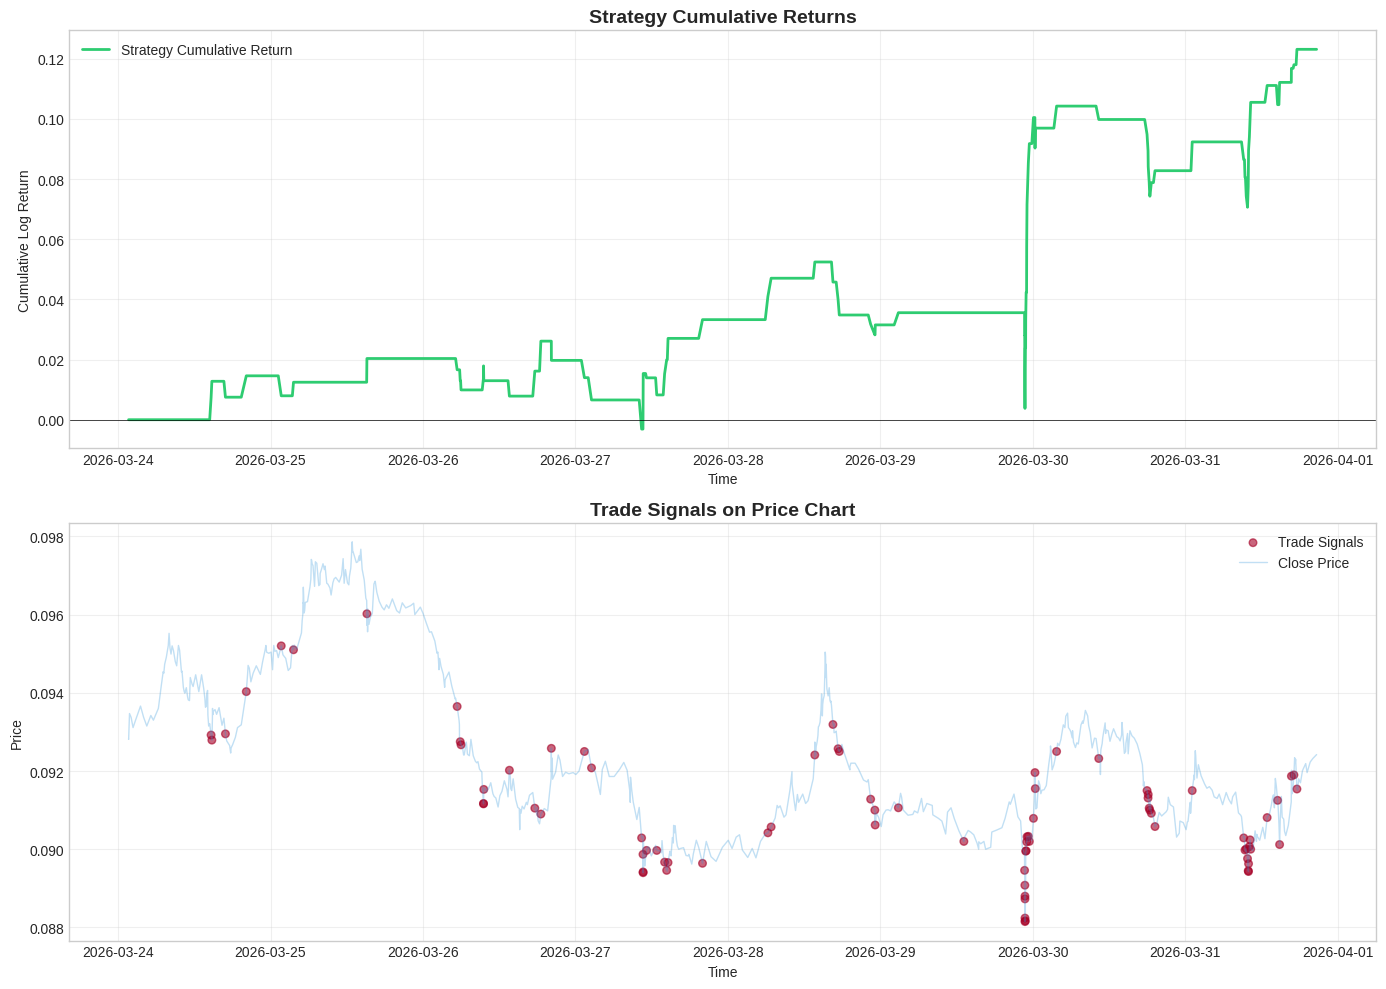


策略表现统计
总交易次数: 82
盈利交易次数: 47
胜率: 57.32%
单笔平均收益 (simple): 0.15%
累积收益 (log): 0.1231
累积收益 (simple): 13.10%


In [17]:
# 无泄漏回测：train 训练主模型，validation 训练 meta，test 最终回测
def backtest_strategy(df_model, main_model, meta_model, scaler, feature_cols, test_start_idx):
    """
    回测策略：
    1. 主模型预测方向
    2. Meta模型决定是否交易
    3. 使用 Triple Barrier 的真实退出收益计算策略表现
    """
    
    # 测试集数据
    df_test = df_model.iloc[test_start_idx:].copy()
    X_test_primary = scaler.transform(df_test[feature_cols].values)
    
    # 主模型预测
    main_proba = main_model.predict_proba(X_test_primary)[:, 1]
    main_pred = (main_proba > 0.5).astype(int)
    
    # Meta模型预测（是否执行交易）
    meta_features = np.column_stack([main_proba, X_test_primary])
    meta_proba = meta_model.predict_proba(meta_features)[:, 1]
    trade_decision = ((main_pred == 1) & (meta_proba > 0.5)).astype(int)
    
    # 使用 Triple Barrier 的真实退出收益
    df_test['main_pred'] = main_pred
    df_test['main_proba'] = main_proba
    df_test['meta_proba'] = meta_proba
    df_test['trade_decision'] = trade_decision
    df_test['strategy_return'] = df_test['tb_log_return'] * df_test['trade_decision']
    df_test['strategy_return_simple'] = (np.exp(df_test['tb_log_return']) - 1) * df_test['trade_decision']
    df_test['cumulative_return'] = df_test['strategy_return'].cumsum()
    
    return df_test

# 执行回测
df_backtest = backtest_strategy(df_model, rf_model, meta_model, scaler, feature_cols, val_end)

# 可视化结果
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 累积收益曲线
axes[0].plot(df_backtest.index, df_backtest['cumulative_return'], 
            color='#2ecc71', linewidth=2, label='Strategy Cumulative Return')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_title('Strategy Cumulative Returns', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Cumulative Log Return')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 交易信号分布
trade_signals = df_backtest[df_backtest['trade_decision'] == 1]
axes[1].scatter(trade_signals.index, trade_signals['close'], 
               c=trade_signals['main_pred'], cmap='RdYlGn', 
               s=30, alpha=0.6, label='Trade Signals')
axes[1].plot(df_backtest.index, df_backtest['close'], 
            color='#3498db', alpha=0.3, linewidth=1, label='Close Price')
axes[1].set_title('Trade Signals on Price Chart', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Price')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# 策略统计
total_trades = df_backtest['trade_decision'].sum()
executed_trades = df_backtest[df_backtest['trade_decision'] == 1].copy()
winning_trades = (executed_trades['strategy_return'] > 0).sum()
total_return = df_backtest['cumulative_return'].iloc[-1]
avg_trade_return = executed_trades['strategy_return_simple'].mean() if len(executed_trades) > 0 else 0

print("\n" + "="*60)
print("策略表现统计")
print("="*60)
print(f"总交易次数: {total_trades}")
print(f"盈利交易次数: {winning_trades}")
print(f"胜率: {winning_trades/total_trades:.2%}" if total_trades > 0 else "胜率: N/A")
print(f"单笔平均收益 (simple): {avg_trade_return:.2%}" if total_trades > 0 else "单笔平均收益 (simple): N/A")
print(f"累积收益 (log): {total_return:.4f}")
print(f"累积收益 (simple): {np.exp(total_return)-1:.2%}")

## 8. 总结与下一步

### 已完成：
1. ✅ 加载Dollar Bars数据
2. ✅ 计算对数收益率
3. ✅ 使用Triple Barrier Method生成标签
4. ✅ 特征工程（波动率、动量、成交量等）
5. ✅ 训练主模型（Random Forest, Gradient Boosting）
6. ✅ 应用Meta-Labeling进行二次过滤
7. ✅ 简化回测

### 下一步建议：
1. 优化Triple Barrier参数（pt_sl_multiplier, horizon）
2. 尝试更多模型（XGBoost, LightGBM, Neural Networks）
3. 添加更多特征（市场微观结构特征、订单流特征）
4. 完善回测框架（考虑交易成本、滑点）
5. 使用Walk-Forward验证而非简单train-test split
6. 尝试其他信息驱动Bars（Tick Imbalance, Volume Run等）对比效果